# IT Support Dashboard - Supporting Notebook 4

This notebook continues from Notebook 3 by converting text recurrence signals into operationally interpretable clusters. It selects a robust `K`, labels clusters, and derives a prioritisation score for action planning.

## Clustering And Actionability Scoring

This notebook applies `K-Means` to normalised `TF-IDF` vectors, evaluates candidate `K` values, and ranks resulting clusters by operational relevance.

Workflow summary:
- load sparse downstream `TF-IDF` features from Notebook 3 outputs
- evaluate configured `K` range with separation and over-segmentation checks
- select efficient screening initialisation via an adaptive `n_init` probe
- run targeted high-budget sensitivity checks
- choose final `K` using `Composite Score = Silhouette Score - Redundant Pair Ratio`
- generate cluster labels and derive `Actionability Score`

Value: this stage converts recurrence evidence into a reproducible prioritisation framework.

### Importing

Packages are imported, directories are validated, and downstream `TF-IDF` artefacts are loaded with sparse-first logic.

Value: this preserves feature fidelity while reducing memory overhead in clustering computations.

In [1]:
# Importing essential packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time
from scipy import sparse

# Add project root to sys.path by searching upward for config.py
project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists()), None
)
if project_root is None:
    raise FileNotFoundError("Could not locate project root containing config.py")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config import Config  # noqa: E402

Config.ensure_directories()

# Prefer sparse TF-IDF export for downstream clustering efficiency.
tfidf_sparse = sparse.load_npz(Config.TFIDF_SPARSE_MATRIX_PATH).astype(np.float32)
feature_names = np.load(Config.TFIDF_FEATURE_NAMES_PATH, allow_pickle=True)

[Config] Verified project directory structure under C:\Users\David\Desktop\Python_Files\IT-Support-Ticket-Analysis


### Evaluating K Values

Candidate `K` values are screened using `Silhouette Score`, `Davies-Bouldin Score`, and median cluster-size thresholds.

Value: this stage narrows the search to viable candidates while controlling over-segmentation risk and runtime.

In [2]:
# Normalise TF-IDF once and keep it sparse for faster clustering
tfidf_normalised = normalize(tfidf_sparse, norm="l2", copy=False)
n_samples = tfidf_normalised.shape[0]  # use the actual sample being clustered

### N_init Probe

A representative `K` is used to select the minimum viable screening `n_init` before full-range evaluation.

Value: this reduces total screening cost while retaining reference-quality initialisation behaviour.

In [3]:
# n_init candidates in use across this notebook: [1, 5, 10, 20]
# Probe selects the minimum viable screening value from {1, 2, 3, 4, Config.KMEANS_SCREENING_N_INIT}.

# Derive a representative probe K: the largest K satisfying all threshold
# minimum-cluster-size constraints simultaneously.
# Balanced-clustering bound: K <= floor(1 / most_restrictive_threshold).
probe_k = int(1.0 / max(Config.THRESHOLD_PERCENTS))

# Materialise the full dense matrix once for silhouette calculations.
# Reused by both the screening loop and the later sensitivity check.
tfidf_dense = tfidf_sparse.toarray()

print(f"Probing n_init candidates at K={probe_k} (up to ~6 mins)...")

# Reference score (typically n_init=5).
_probe_labels_ref = KMeans(
    n_clusters=probe_k,
    random_state=Config.RANDOM_STATE,
    n_init=Config.KMEANS_SCREENING_N_INIT,
).fit_predict(tfidf_normalised)
_sil_ref = silhouette_score(tfidf_dense, _probe_labels_ref)
del _probe_labels_ref

probe_log = [f"n_init={Config.KMEANS_SCREENING_N_INIT} (ref) -> sil={_sil_ref:.6f}"]

# Escalate from n_init=1 upward, stopping as soon as a candidate matches or beats the reference.
# Best case: 2 KMeans fits total. Worst case: 5 (all candidates exhausted).
screening_n_init = Config.KMEANS_SCREENING_N_INIT
for candidate_n_init in [1, 2, 3, 4]:
    _probe_labels = KMeans(
        n_clusters=probe_k,
        random_state=Config.RANDOM_STATE,
        n_init=candidate_n_init,
    ).fit_predict(tfidf_normalised)
    _sil = silhouette_score(tfidf_dense, _probe_labels)
    del _probe_labels

    probe_log.append(f"n_init={candidate_n_init} -> sil={_sil:.6f}")
    if _sil >= _sil_ref:
        screening_n_init = candidate_n_init
        break

print(f"n_init probe at K={probe_k}:")
for entry in probe_log:
    print(f"  {entry}")
print(f"Selected screening n_init: {screening_n_init}")

Probing n_init candidates at K=50 (up to ~6 mins)...
n_init probe at K=50:
  n_init=5 (ref) -> sil=0.026260
  n_init=1 -> sil=0.024849
  n_init=2 -> sil=0.024849
  n_init=3 -> sil=0.024849
  n_init=4 -> sil=0.024849
Selected screening n_init: 5


### K-Means Screening

Candidate `K` values are evaluated with the selected `n_init`, and results are visualised for interpretability.

In [4]:
# Define K search range from config; screening_n_init was selected by the probe above.
k_values = Config.K_SEARCH_RANGE

print(
    f"Evaluating KMeans clustering metrics across K values ({min(k_values)}-{max(k_values)}) "
    f"with screening n_init={screening_n_init} (60-90mins)..."
)

# Cache labels for every K in the screening range (used for diagnostics/reuse)
kmeans_labels_cache = {}

# Compute clustering metrics once per K
records = []
print(
    f"Evaluating KMeans for K={min(k_values)}-{max(k_values)} "
    f"(cut-offs based on n={n_samples:,})..."
)

# Identify K values that yield median cluster sizes around the defined thresholds
for k in k_values:
    # Record runtime because this is the most expensive step
    start_time = time.time()
    kmeans_model = KMeans(
        n_clusters=k, random_state=Config.RANDOM_STATE, n_init=screening_n_init
    )
    cluster_labels = kmeans_model.fit_predict(tfidf_normalised)
    kmeans_labels_cache[k] = cluster_labels

    # Compute silhouette and Davies-Bouldin scores on the full dataset.
    unique_labels = np.unique(cluster_labels)
    if unique_labels.size > 1:
        silhouette_avg = silhouette_score(tfidf_dense, cluster_labels)
        davies_bouldin_avg = davies_bouldin_score(tfidf_dense, cluster_labels)
    else:
        silhouette_avg = np.nan
        davies_bouldin_avg = np.nan

    cluster_sizes = np.bincount(cluster_labels)
    median_cluster_size = float(np.median(cluster_sizes))
    runtime_seconds = time.time() - start_time

    # Record results for this K
    records.append(
        {
            "K Value": k,
            "Silhouette Score": silhouette_avg,
            "Davies-Bouldin Score": davies_bouldin_avg,
            "Median Cluster Size": median_cluster_size,
            "Runtime (sec)": runtime_seconds,
            "n_init (Screening)": screening_n_init,
        }
    )

    # Print progress for this K
    print(
        f"K={k:<2d} | silhouette={silhouette_avg:.5f} | DB={davies_bouldin_avg:.3f} | "
        f"median={median_cluster_size:.0f} | runtime={runtime_seconds:.1f}s"
    )

# Compile results into a DataFrame and sort by K Value
metrics_df = pd.DataFrame(records).sort_values("K Value").reset_index(drop=True)
metrics_df["Silhouette Score (x10e-2)"] = metrics_df["Silhouette Score"] * 100

# Save metrics to CSV for sharing and to parquet to skip this cell in future runs
metrics_df.to_csv(Config.KMEANS_CSV_PATH, index=False, encoding="utf-8")
metrics_df.to_parquet(
    Config.KMEANS_PARQUET_PATH, engine="pyarrow", compression="snappy"
)

display(
    metrics_df.style.format(
        {
            "Silhouette Score": "{:.3f}",
            "Davies-Bouldin Score": "{:.3f}",
            "Median Cluster Size": "{:.0f}",
            "Runtime (sec)": "{:.1f}",
            "n_init (Screening)": "{:.0f}",
        }
    )
)

Evaluating KMeans clustering metrics across K values (20-80) with screening n_init=5 (60-90mins)...
Evaluating KMeans for K=20-80 (cut-offs based on n=13,729)...
K=20 | silhouette=0.02091 | DB=5.793 | median=588 | runtime=44.9s
K=21 | silhouette=0.02265 | DB=5.730 | median=599 | runtime=44.9s
K=22 | silhouette=0.02637 | DB=5.712 | median=545 | runtime=45.4s
K=23 | silhouette=0.02558 | DB=5.638 | median=545 | runtime=44.2s
K=24 | silhouette=0.02474 | DB=5.636 | median=510 | runtime=45.2s
K=25 | silhouette=0.02487 | DB=5.547 | median=508 | runtime=46.1s
K=26 | silhouette=0.02527 | DB=5.508 | median=518 | runtime=46.5s
K=27 | silhouette=0.02544 | DB=5.493 | median=476 | runtime=46.0s
K=28 | silhouette=0.02508 | DB=5.541 | median=492 | runtime=46.2s
K=29 | silhouette=0.02573 | DB=5.334 | median=447 | runtime=46.6s
K=30 | silhouette=0.02352 | DB=5.657 | median=434 | runtime=47.3s
K=31 | silhouette=0.02429 | DB=5.427 | median=411 | runtime=47.3s
K=32 | silhouette=0.02082 | DB=5.635 | median=

,K Value,Silhouette Score,Davies-Bouldin Score,Median Cluster Size,Runtime (sec),n_init (Screening),Silhouette Score (x10e-2)
0,20,0.021,5.793,588,44.9,5,2.091454
1,21,0.023,5.730,599,44.9,5,2.265133
2,22,0.026,5.712,545,45.4,5,2.636550
3,23,0.026,5.638,545,44.2,5,2.557913
4,24,0.025,5.636,510,45.2,5,2.474342
5,25,0.025,5.547,508,46.1,5,2.486589
6,26,0.025,5.508,518,46.5,5,2.527138
7,27,0.025,5.493,476,46.0,5,2.543851
8,28,0.025,5.541,492,46.2,5,2.508102
9,29,0.026,5.334,447,46.6,5,2.573203


### Finding The Optimal K

Shortlisted candidates are evaluated through threshold constraints, sensitivity checks, and composite scoring.

Value: this provides a transparent final-model decision that balances structural quality and thematic distinctness.

In [5]:
# Importing KMeans results from parquet (can skip clustering cell if already done)
metrics_df = pd.read_parquet(Config.KMEANS_PARQUET_PATH, engine="pyarrow")
metrics_df["Silhouette Score (x10e-2)"] = metrics_df["Silhouette Score"] * 100

# Prerequisite: tfidf_normalised must already exist from the previous preprocessing cell
n_samples = tfidf_normalised.shape[0]

# Thresholds are % of this sample size for the median cluster size
threshold_percents = Config.THRESHOLD_PERCENTS
threshold_abs = {t: n_samples * t for t in threshold_percents}

# For each threshold, pick the best k that is NOT over-segmented
optimal_rows = []
for threshold_perc in threshold_percents:
    cutoff = threshold_abs[threshold_perc]
    eligible_df = metrics_df[metrics_df["Median Cluster Size"] >= cutoff]

    if eligible_df.empty:
        chosen_row = metrics_df.loc[metrics_df["Silhouette Score"].idxmax()].copy()
        chosen_row["Note"] = "fallback_all_oversegmented"
        chosen_row["Oversegmentation"] = "True"
    else:
        chosen_row = (
            eligible_df.sort_values(
                ["Silhouette Score", "Davies-Bouldin Score"],
                ascending=[False, True],
            )
            .iloc[0]
            .copy()
        )
        chosen_row["Oversegmentation"] = "False"

    chosen_row["Threshold Proportion"] = threshold_perc
    chosen_row["Threshold Percent"] = f"{threshold_perc * 100:g}%"
    chosen_row["Threshold Abs"] = cutoff
    optimal_rows.append(chosen_row)

optimal_df = (
    pd.DataFrame(optimal_rows)
    .rename(columns={"K Value": "Optimal K"})
    .drop(columns=["Runtime (sec)"])
)

optimal_df = optimal_df[
    [
        "Threshold Proportion",
        "Threshold Percent",
        "Threshold Abs",
        "Optimal K",
        "Silhouette Score",
        "Silhouette Score (x10e-2)",
        "Davies-Bouldin Score",
        "Median Cluster Size",
        "Oversegmentation",
    ]
]

optimal_df.to_csv(Config.OPTIMAL_K_PATH, index=False, encoding="utf-8")

display(
    optimal_df.drop(columns=["Threshold Proportion"]).style.format(
        {
            "Threshold Abs": "{:,}",
            "Silhouette Score": "{:.3e}",
            "Silhouette Score (x10e-2)": "{:.3f}",
            "Davies-Bouldin Score": "{:.3f}",
            "Median Cluster Size": "{:.0f}",
            "Optimal K": "{:.0f}",
        }
    )
)

,Threshold Percent,Threshold Abs,Optimal K,Silhouette Score,Silhouette Score (x10e-2),Davies-Bouldin Score,Median Cluster Size,Oversegmentation
52,1%,137.29,72,2.803e-02,2.803,4.954,187,False
41,1.5%,205.935,61,2.779e-02,2.779,4.854,216,False
24,2%,274.58,44,2.638e-02,2.638,5.126,315,False


### Visualising Silhouette Scores

This visual shows score behaviour across `K` and highlights threshold-selected candidates.

Value: it supports interpretation of model selection decisions but does not replace the formal composite ranking rule.


Silhouette scores across K values:


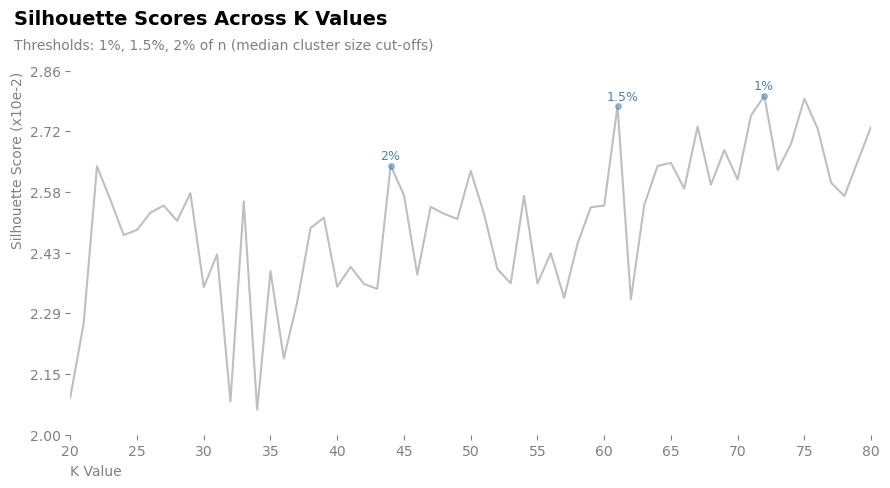

In [6]:
# Initialise the matplotlib figure
f, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=metrics_df,
    x="K Value",
    y="Silhouette Score (x10e-2)",
    color="grey",
    alpha=0.5,
)

# Coordinates of the optimal K by threshold for annotation
for i, row in optimal_df.iterrows():
    ax.annotate(
        f"{row['Threshold Percent']}",
        xy=(row["Optimal K"], row["Silhouette Score (x10e-2)"]),
        xytext=(row["Optimal K"] - 0.8, row["Silhouette Score (x10e-2)"] + 0.014),
        fontsize=9,
        color="steelblue",
    )
    ax.plot(
        row["Optimal K"],
        row["Silhouette Score (x10e-2)"],
        "o",
        color="steelblue",
        markersize=4,
        alpha=0.5,
    )

# Clean borders by removing bottom/right spines
sns.despine(right=True, top=True, left=True, bottom=True)

# Set labels and markers to grey for subtlety
ax.set_xlabel("K Value", color="grey")
ax.set_ylabel("Silhouette Score (x10e-2)", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# Set axis alignment and position to the left for better aesthetics
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Remove horizontal padding so the line starts at the y-axis
ax.set_xlim(metrics_df["K Value"].min(), metrics_df["K Value"].max())

# Use data-driven y limits and ticks for robustness
ymin = metrics_df["Silhouette Score (x10e-2)"].min()
ymax = metrics_df["Silhouette Score (x10e-2)"].max()
ypad = max((ymax - ymin) * 0.08, 0.02)
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.xaxis.set_ticks(
    np.arange(metrics_df["K Value"].min(), metrics_df["K Value"].max() + 1, 5)
)
ax.yaxis.set_ticks(np.linspace(ymin - ypad, ymax + ypad, 7))

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))

# Title parameters
ax.set_title(
    label="Silhouette Scores Across K Values",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=15,
    loc="left",
    x=-0.07,
    y=1.07,
)

# Add subtitle in axes coordinates so it stays in place across scales
ax.text(
    x=-0.07,
    y=1.05,
    s="Thresholds: 1%, 1.5%, 2% of n (median cluster size cut-offs)",
    fontsize=10,
    color="grey",
    ha="left",
    va="bottom",
    transform=ax.transAxes,
)

plt.tight_layout()
plt.savefig(Config.KMEANS_PLOT_PATH, dpi=300, bbox_inches="tight")

print("\nSilhouette scores across K values:")
plt.show()

In [7]:
# Sensitivity check: does increasing n_init to Config.KMEANS_SENSITIVITY_N_INIT
# materially improve on the probe-selected screening baseline?

# Use the K selected by the most restrictive threshold as the single representative
# candidate — this K satisfies ALL threshold constraints simultaneously, so one
# re-fit is sufficient as a proxy for the full shortlist.
most_restrictive_idx = optimal_df["Threshold Proportion"].idxmax()
candidate_k_values = [int(optimal_df.loc[most_restrictive_idx, "Optimal K"])]

sensitivity_rows = []
sensitivity_n_init = Config.KMEANS_SENSITIVITY_N_INIT

# Resolve the screening baseline used for column labelling.
# Falls back to Config.KMEANS_SCREENING_N_INIT if the probe cell was skipped
# (e.g. results loaded directly from parquet).
_screening_n_init_label = (
    screening_n_init if "screening_n_init" in dir() else Config.KMEANS_SCREENING_N_INIT
)

for candidate_k in candidate_k_values:
    baseline_row = metrics_df.loc[metrics_df["K Value"] == candidate_k].iloc[0]
    silhouette_baseline = float(baseline_row["Silhouette Score"])
    davies_baseline = float(baseline_row["Davies-Bouldin Score"])

    labels_high = KMeans(
        n_clusters=candidate_k,
        random_state=Config.RANDOM_STATE,
        n_init=sensitivity_n_init,
    ).fit_predict(tfidf_normalised)

    silhouette_high = float(silhouette_score(tfidf_dense, labels_high))
    davies_high = float(davies_bouldin_score(tfidf_dense, labels_high))
    del labels_high

    sensitivity_rows.append(
        {
            "K Value": candidate_k,
            f"Silhouette (n_init={_screening_n_init_label})": silhouette_baseline,
            f"Silhouette (n_init={sensitivity_n_init})": silhouette_high,
            "Silhouette Delta": silhouette_high - silhouette_baseline,
            f"Davies-Bouldin (n_init={_screening_n_init_label})": davies_baseline,
            f"Davies-Bouldin (n_init={sensitivity_n_init})": davies_high,
            "Davies-Bouldin Delta": davies_high - davies_baseline,
        }
    )

ninit_sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values("K Value")
ninit_sensitivity_df.to_csv(
    Config.NINIT_SENSITIVITY_PATH, index=False, encoding="utf-8"
)

print("\nn_init sensitivity for the most-restrictive-threshold candidate K:")
display(
    ninit_sensitivity_df.style.format(
        {
            f"Silhouette (n_init={_screening_n_init_label})": "{:.6f}",
            f"Silhouette (n_init={sensitivity_n_init})": "{:.6f}",
            "Silhouette Delta": "{:+.6f}",
            f"Davies-Bouldin (n_init={_screening_n_init_label})": "{:.6f}",
            f"Davies-Bouldin (n_init={sensitivity_n_init})": "{:.6f}",
            "Davies-Bouldin Delta": "{:+.6f}",
        }
    )
)

# Release the dense matrix. If it was created here (parquet path), release it now;
# if it came from the probe cell, also release it — screening loop is complete.
del tfidf_dense


n_init sensitivity for the most-restrictive-threshold candidate K:


,K Value,Silhouette (n_init=5),Silhouette (n_init=20),Silhouette Delta,Davies-Bouldin (n_init=5),Davies-Bouldin (n_init=20),Davies-Bouldin Delta
0,44,0.026382,0.026382,+0.000000,5.125739,5.125739,+0.000000


### Redundancy Ratio And Composite Scoring

This section penalises thematic overlap between clusters and combines it with silhouette quality.

Rule used:
- `Composite Score = Silhouette Score - Redundant Pair Ratio`

Value: this prevents selection of high-`K` solutions that improve separation marginally but duplicate themes heavily.

In [8]:
# Compute redundant-cluster-pair ratio for each optimal K threshold
def compute_redundancy_ratio(cluster_labels_map: dict) -> float:
    """Proportion of cluster pairs sharing >= configured top-term overlap."""
    label_sets = {
        cid: set(lbl.split(", ")) if isinstance(lbl, str) else set()
        for cid, lbl in cluster_labels_map.items()
    }
    cluster_ids = list(label_sets.keys())
    all_pairs = [
        (a, b) for i, a in enumerate(cluster_ids) for b in cluster_ids[i + 1 :]
    ]
    if not all_pairs:
        return 0.0

    redundant_pairs = 0
    for a, b in all_pairs:
        smaller = min(len(label_sets[a]), len(label_sets[b]))
        if (
            smaller > 0
            and len(label_sets[a] & label_sets[b]) / smaller
            >= Config.REDUNDANCY_OVERLAP_THRESHOLD
        ):
            redundant_pairs += 1
    return redundant_pairs / len(all_pairs)


def build_labels_map(
    k: int, cluster_ids: np.ndarray, feature_names: np.ndarray, tfidf_matrix
) -> dict:
    """Build a top-term label per cluster using O(n) argpartition."""
    labels_map = {}
    top_term_count = Config.REDUNDANCY_LABEL_TOP_TERMS
    for cid in range(k):
        member_idx = np.where(cluster_ids == cid)[0]
        if len(member_idx) == 0:
            labels_map[cid] = "Empty Cluster"
            continue
        mean_vec = np.array(tfidf_matrix[member_idx].mean(axis=0)).ravel()
        top_idx = np.argpartition(mean_vec, -top_term_count)[-top_term_count:]
        top_idx = top_idx[np.argsort(mean_vec[top_idx])[::-1]]
        labels_map[cid] = ", ".join(feature_names[top_idx])
    return labels_map


print("Computing redundancy ratios for optimal K values (1-2mins)...")

finalist_n_init = Config.KMEANS_FINALIST_N_INIT

# Finalist stage uses stronger initialisation for robustness
finalist_model_cache: dict = {}
finalist_labels_cache: dict = {}
redundancy_values = []

for _, opt_row in optimal_df.iterrows():
    best_k = int(opt_row["Optimal K"])
    if best_k not in finalist_model_cache:
        finalist_model_cache[best_k] = KMeans(
            n_clusters=best_k, random_state=Config.RANDOM_STATE, n_init=finalist_n_init
        ).fit(tfidf_normalised)
        finalist_labels_cache[best_k] = finalist_model_cache[best_k].labels_
    labels_map = build_labels_map(
        best_k, finalist_labels_cache[best_k], feature_names, tfidf_normalised
    )
    redundancy_values.append(compute_redundancy_ratio(labels_map))

# Composite score: maximise silhouette, minimise redundancy
optimal_df["Redundant Pair Ratio"] = redundancy_values
optimal_df["Composite Score"] = (
    optimal_df["Silhouette Score"] - optimal_df["Redundant Pair Ratio"]
)
optimal_df["n_init (Finalist)"] = finalist_n_init
optimal_df = optimal_df.sort_values("Composite Score", ascending=False)

optimal_k = int(optimal_df.iloc[0]["Optimal K"])
print(f"Chosen optimal K: {optimal_k}")

display(optimal_df)

Computing redundancy ratios for optimal K values (1-2mins)...
Chosen optimal K: 44


,Threshold Proportion,Threshold Percent,Threshold Abs,Optimal K,Silhouette Score,Silhouette Score (x10e-2),Davies-Bouldin Score,Median Cluster Size,Oversegmentation,Redundant Pair Ratio,Composite Score,n_init (Finalist)
24,0.020,2%,274.580,44.0,0.026382,2.638224,5.125739,315.0,False,0.025370,0.001012,10
41,0.015,1.5%,205.935,61.0,0.027786,2.778577,4.854280,216.0,False,0.029508,-0.001722,10
52,0.010,1%,137.290,72.0,0.028025,2.802522,4.953633,187.0,False,0.031690,-0.003665,10


### Cluster Labels

Final cluster labels are generated from top `TF-IDF` terms per cluster.

Value: this converts numerical clusters into interpretable operational themes.

In [9]:
# Importing the last dataset for final clustering and labelling
df = pd.read_parquet(Config.LEMMA_PARQUET_PATH, engine="pyarrow")

# Final clustering using optimal_k
finalist_n_init = (
    int(optimal_df["n_init (Finalist)"].iloc[0])
    if "n_init (Finalist)" in optimal_df.columns
    else Config.KMEANS_FINALIST_N_INIT
)

if "finalist_model_cache" in globals() and optimal_k in finalist_model_cache:
    print(
        f"Reusing finalist-stage fitted model for k={optimal_k} "
        f"(n_init={finalist_n_init})..."
    )
    kmeans = finalist_model_cache[optimal_k]
    df["KMeans Cluster"] = kmeans.labels_
else:
    print(
        f"Performing final KMeans clustering with k={optimal_k} "
        f"(n_init={finalist_n_init}) (30-60s)..."
    )
    kmeans = KMeans(
        n_clusters=optimal_k, random_state=Config.RANDOM_STATE, n_init=finalist_n_init
    )
    df["KMeans Cluster"] = kmeans.fit_predict(tfidf_normalised)

# Generate top TF-IDF term labels for each cluster
labels_map, label_rows = {}, []
top_term_count = Config.REDUNDANCY_LABEL_TOP_TERMS

for cid in range(optimal_k):
    idx = np.where(df["KMeans Cluster"] == cid)[0]
    if len(idx) == 0:
        labels_map[cid] = "Empty Cluster"
        label_rows.append(
            {"Cluster ID": cid, "Keywords": "Empty Cluster", "Records": 0}
        )
        continue

    mean_vec = np.array(tfidf_normalised[idx].mean(axis=0)).ravel()
    top_idx = np.argpartition(mean_vec, -top_term_count)[-top_term_count:]
    top_idx = top_idx[np.argsort(mean_vec[top_idx])[::-1]]
    label_text = ", ".join(feature_names[top_idx])
    labels_map[cid] = label_text
    label_rows.append({"Cluster ID": cid, "Keywords": label_text, "Records": len(idx)})

cluster_labels_df = pd.DataFrame(label_rows).sort_values(by="Records", ascending=False)
df["Cluster Label"] = df["KMeans Cluster"].map(labels_map)

print("Generated cluster label summary:")
display(cluster_labels_df)
cluster_labels_df.to_csv(Config.CLUSTER_LABELS_PATH, index=False)

Reusing finalist-stage fitted model for k=44 (n_init=10)...
Generated cluster label summary:


,Cluster ID,Keywords,Records
2,2,"investment, analytic, data analytic, data, too...",787
22,22,"issue, software, update, problem, integration,...",680
12,12,"integration, integrate, documentation, step, s...",624
23,23,"integration, analytic, team, support, provide,...",593
37,37,"access, unauthorized, unauthorized access, sec...",536
5,5,"security, breach, security breach, incident, m...",536
39,39,"connectivity, network, device, issue, problem,...",450
15,15,"brand, digital, growth, brand growth, digital ...",404
43,43,"outage, service, service outage, issue, disrup...",382
14,14,"server, dashboard, issue, load, project dashbo...",376


### Actionability Scoring

Each cluster receives an `Actionability Score` built from:
- cohesion contribution
- high-similarity concentration

Value: this translates cluster structure into actionable prioritisation for service improvement.

In [10]:
# Compute cohesion & actionability using centroid-based cosine similarity
# Build per-ticket similarity to assigned KMeans centroid (TF-IDF space)
cluster_ids = df["KMeans Cluster"].to_numpy()
centroids = kmeans.cluster_centers_
centroid_norms = np.linalg.norm(centroids, axis=1)

centroid_similarity = np.zeros(len(cluster_ids), dtype=np.float32)
for cid in range(optimal_k):
    idx = np.where(cluster_ids == cid)[0]
    if len(idx) == 0:
        continue
    denom = centroid_norms[cid]
    if denom == 0:
        continue
    centroid_similarity[idx] = (
        np.asarray(tfidf_normalised[idx].dot(centroids[cid])).ravel() / denom
    )

# Prepare analysis dataframe aligned to clustering output
actionability_df = pd.DataFrame(
    {
        "KMeans Cluster": cluster_ids,
        "Mean Similarity": centroid_similarity,
    }
)
actionability_df["Cluster Label"] = actionability_df["KMeans Cluster"].map(labels_map)

# Cluster-level cohesion summary
cluster_summary_df = (
    actionability_df.groupby("KMeans Cluster", observed=False)
    .agg(
        Cluster_Size=("KMeans Cluster", "size"),
        Mean_Similarity=("Mean Similarity", "mean"),
    )
    .reset_index()
)
cluster_summary_df["Cluster Label"] = cluster_summary_df["KMeans Cluster"].map(
    labels_map
)
cluster_summary_df["Cohesion"] = (
    cluster_summary_df["Mean_Similarity"]
    * cluster_summary_df["Cluster_Size"]
    / len(actionability_df)
)

cluster_summary_df = cluster_summary_df.sort_values("Cohesion", ascending=False)
cluster_summary_df.to_csv(Config.CLUSTER_SUMMARY_PATH, encoding="utf-8", index=False)

print("\nActionability per ticket:")
display(actionability_df)

print("\nCluster-level cohesion summary:")
display(cluster_summary_df)


Actionability per ticket:


,KMeans Cluster,Mean Similarity,Cluster Label
0,43,0.382551,"outage, service, service outage, issue, disrup..."
1,23,0.263014,"integration, analytic, team, support, provide,..."
2,29,0.453776,"billing, payment, plan, option, pricing, discount"
3,16,0.314980,"marketing, agency, marketing agency, issue, di..."
4,23,0.306655,"integration, analytic, team, support, provide,..."
...,...,...,...
13724,36,0.448570,"billing, discrepancy, payment, billing discrep..."
13725,10,0.487383,"breach, data breach, data, security, medical, ..."
13726,18,0.441849,"data analytic, analytic, data, issue, analytic..."
13727,1,0.343464,"request, integration, project, user, project m..."



Cluster-level cohesion summary:


,KMeans Cluster,Cluster_Size,Mean_Similarity,Cluster Label,Cohesion
2,2,787,0.436699,"investment, analytic, data analytic, data, too...",0.025033
37,37,536,0.466012,"access, unauthorized, unauthorized access, sec...",0.018194
5,5,536,0.449316,"security, breach, security breach, incident, m...",0.017542
12,12,624,0.355970,"integration, integrate, documentation, step, s...",0.016179
15,15,404,0.528351,"brand, digital, growth, brand growth, digital ...",0.015548
22,22,680,0.302462,"issue, software, update, problem, integration,...",0.014981
10,10,373,0.492293,"breach, data breach, data, security, medical, ...",0.013375
4,4,375,0.477569,"marketing, digital marketing, digital, brand, ...",0.013045
11,11,344,0.495446,"security, medical, datum, protocol, medical da...",0.012414
3,3,320,0.521922,"medical, security, datum, medical datum, encry...",0.012165


### Top 10 Clusters

Clusters are ranked by normalised `Actionability Score` and the top ten are reported.

Value: this produces a concise intervention shortlist for operational planning and reporting.

In [11]:
# Create actionability ranking based on cohesion contribution and high-similarity concentration
overall_median_similarity = actionability_df["Mean Similarity"].median()

# Flag each ticket as High (above median similarity) or Low
actionability_df["Similarity Tier"] = np.where(
    actionability_df["Mean Similarity"] >= overall_median_similarity, "High", "Low"
)

actionability_df.to_csv(Config.ACTIONABILITY_PATH, encoding="utf-8", index=False)

# Compute per-cluster proportion of High-tier tickets
ratio_df = (
    actionability_df.groupby("KMeans Cluster", observed=False)["Similarity Tier"]
    .value_counts(normalize=True)
    .rename("Ratio")
    .reset_index()
)

high_ratio = ratio_df.loc[
    ratio_df["Similarity Tier"] == "High", ["KMeans Cluster", "Ratio"]
].rename(columns={"Ratio": "High Ratio"})

# Merge cohesion by cluster (safe alignment; keep all clusters)
actionability_dist = cluster_summary_df[
    ["KMeans Cluster", "Cohesion", "Cluster Label"]
].merge(high_ratio, on="KMeans Cluster", how="left")

# Fill clusters with no High tickets
actionability_dist["High Ratio"] = actionability_dist["High Ratio"].fillna(0.0)

# Map records from cluster_labels_df to actionability_dist (safe alignment)
records_map = cluster_labels_df.set_index("Cluster ID")["Records"].to_dict()
actionability_dist["Records"] = actionability_dist["KMeans Cluster"].map(records_map)

cohesion_max = actionability_dist["Cohesion"].max()
high_ratio_max = actionability_dist["High Ratio"].max()

if pd.isna(cohesion_max) or cohesion_max == 0:
    cohesion_max = 1.0
if pd.isna(high_ratio_max) or high_ratio_max == 0:
    high_ratio_max = 1.0

# Raw weighted score, then normalised to 0-1 for easier interpretation
raw_actionability = Config.CLUSTER_ACTIONABILITY_COHESION_WEIGHT * (
    actionability_dist["Cohesion"] / cohesion_max
) + Config.CLUSTER_ACTIONABILITY_HIGH_RATIO_WEIGHT * (
    actionability_dist["High Ratio"] / high_ratio_max
)
actionability_dist["Actionability Score"] = (
    raw_actionability / Config.CLUSTER_ACTIONABILITY_NORMALISER
)

# Top 10 most actionable clusters
top10_actionable = (
    actionability_dist.sort_values("Actionability Score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)[
    [
        "KMeans Cluster",
        "Records",
        "Cluster Label",
        "Cohesion",
        "High Ratio",
        "Actionability Score",
    ]
]

print("\nTop 10 most actionable clusters:")
display(
    top10_actionable.style.format(
        {
            "Cohesion": "{:.4f}",
            "High Ratio": "{:.2%}",
            "Actionability Score": "{:.4f}",
        }
    )
)

actionability_dist.to_csv(Config.PRIORITY_PATH, encoding="utf-8", index=False)


Top 10 most actionable clusters:


,KMeans Cluster,Records,Cluster Label,Cohesion,High Ratio,Actionability Score
0,2,787,"investment, analytic, data analytic, data, tool, investment strategy",0.0250,56.67%,0.8488
1,15,404,"brand, digital, growth, brand growth, digital strategy, strategy",0.0155,87.62%,0.7342
2,37,536,"access, unauthorized, unauthorized access, security, access attempt, medical",0.0182,68.28%,0.7239
3,5,536,"security, breach, security breach, incident, medical, hospital",0.0175,65.86%,0.6981
4,10,373,"breach, data breach, data, security, medical, hospital",0.0134,86.06%,0.6738
5,3,320,"medical, security, datum, medical datum, encryption, control",0.0122,87.81%,0.6505
6,11,344,"security, medical, datum, protocol, medical datum, security protocol",0.0124,81.40%,0.6314
7,4,375,"marketing, digital marketing, digital, brand, strategy, marketing strategy",0.0130,70.93%,0.6058
8,17,326,"medical, secure, secure medical, medical datum, datum, hospital",0.0114,73.31%,0.5748
9,40,282,"campaign, marketing campaign, marketing, target, engagement, digital",0.0100,78.37%,0.5602


### Findings

Threshold screening produced one candidate per configured cut-off, and final selection used the composite objective:
- `Composite Score = Silhouette Score - Redundant Pair Ratio`

In this run, the selected model balanced separation quality with low thematic overlap and retained interpretability at practical cluster granularity.

Sensitivity diagnostics showed no material benefit from increasing initialisation budget for the representative shortlisted candidate, supporting the two-stage initialisation strategy.

Value delivered:
- reproducible `K` selection logic
- interpretable cluster themes
- prioritised shortlist using `Actionability Score`

This notebook completes the pipeline from representativeness validation and text normalisation to cluster-level operational prioritisation.